In [2]:
# ============================================================
# NOTEBOOK 03 — Experimentos A/B (Semana 6)
# Convertir a .ipynb con: jupytext --to notebook 03_ab_experiments.py
# ============================================================

# Experimentos A/B — Feature Engineering vs Baseline

**Branch:** `experiments/feature-engineering-v1`
**Tesis:** Detección de Posturas Riesgosas en Operadores Perforistas

- **Un cambio único por variante** — no mezclar cambios
- **Mismo split / seed / datos** — para aislar el efecto causal
- **Máximo 3 variantes** — baseline + Var1 + Var2
- **Nombrado técnico claro** — patrón `Modelo_Hiperparámetro_FeatureSet`
- **Trazabilidad completa** — logs CSV + decisión final adoptar/descartar

## Variantes

| Rol | Nombre | Cambio único vs Baseline |
|-----|--------|--------------------------|
| A (baseline) | `RF_n200_baseFeats` | — (referencia) |
| B (Var1) | `RF_n200_biomechFeats` | **features**: +73 biomecánicas de dominio |
| C (Var2) | `XGB_n200_baseFeats` | **modelo**: RF → XGBoost |

## 1. Setup y corrección de directorio de trabajo

In [3]:
import os
import sys
from pathlib import Path

# Asegurar que el directorio de trabajo sea la raíz del proyecto
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(project_root)
sys.path.insert(0, str(project_root / "src"))
print(f"Directorio de trabajo: {project_root}")

Directorio de trabajo: D:\MAESTRÍA AI - UNI\IV SEMESTRE\PROYECTO DE INVESTIGACIÓN II\WORKSPACE_GIT\posture-risk-mining_by_Huaytalla


In [4]:
import numpy as np
import pandas as pd
import yaml
import h5py
from loguru import logger as log

from posture_risk.experiments import (
    build_random_forest, build_gradient_boosting,
    cross_validate_pipeline, load_processed_h5, make_shared_splits,
    XGB_AVAILABLE, XGB_BACKEND,
    append_experiment, make_record,
    build_comparison_table, plot_pr_curves_comparison,
    plot_confusion_matrices_comparison, make_decision,
)

# Cargar configuración del experimento
with open("configs/experiments.yaml") as f:
    cfg = yaml.safe_load(f)

print(f"Experimento  : {cfg['experiment']['name']}")
print(f"Branch       : {cfg['experiment']['branch']}")
print(f"Backend GB   : {XGB_BACKEND}")
print(f"Seed         : {cfg['validation']['seed']}")
print(f"CV strategy  : {cfg['validation']['cv_strategy']} (n={cfg['validation']['n_folds']})")

Experimento  : feature-engineering-v1
Branch       : experiments/feature-engineering-v1
Backend GB   : xgboost
Seed         : 42
CV strategy  : GroupKFold (n=9)


## 2. Carga de datasets — base y biomecánico

El dataset biomecánico se generó previamente:
```bash
python -m posture_risk.experiments.prepare_biomech_dataset --config configs/default.yaml
```

In [5]:
base_h5    = Path(cfg["paths"]["base_h5"])
biomech_h5 = Path(cfg["paths"]["biomech_h5"])

X_base, y, subject_ids = load_processed_h5(base_h5)

if not biomech_h5.exists():
    raise FileNotFoundError(
        f"No existe {biomech_h5}. Genera primero con:\n"
        "  python -m posture_risk.experiments.prepare_biomech_dataset"
    )

with h5py.File(biomech_h5, "r") as f:
    X_biomech_only = f["X_biomech"][:]
    y_check        = f["y"][:]
    subj_check     = f["subject_ids"][:]

# Verificación crítica: alineamiento 1:1 entre ambos HDF5
assert np.array_equal(y, y_check),           "Etiquetas no alineadas entre base y biomech"
assert np.array_equal(subject_ids, subj_check), "Subject IDs no alineados"
print(f"✓ Alineamiento 1:1 verificado: {X_base.shape[0]} ventanas en ambos HDF5")

# Construir feature set Var1 (base + biomecánicas)
X_base_plus_biomech = np.concatenate([X_base, X_biomech_only], axis=1)
print(f"\nFeature sets:")
print(f"  base (Baseline + Var2): {X_base.shape}")
print(f"  base+biomech (Var1)   : {X_base_plus_biomech.shape}")

2026-05-22 14:57:42.278 | INFO     | posture_risk.experiments.ab_runner:load_processed_h5:62 - Dataset base: X=(194205, 297), y=(194205,), sujetos=[1 2 3 4 5 6 7 8 9]


✓ Alineamiento 1:1 verificado: 194205 ventanas en ambos HDF5

Feature sets:
  base (Baseline + Var2): (194205, 297)
  base+biomech (Var1)   : (194205, 370)


## 3. Generación de splits compartidos

In [6]:
SEED   = cfg["validation"]["seed"]
splits = make_shared_splits(y, subject_ids, seed=SEED)

print(f"Splits generados: {len(splits)} folds (uno por sujeto)")
print(f"Estos mismos splits se aplicarán a las 3 variantes para garantizar")
print(f"que cualquier diferencia en métricas sea atribuible al cambio único de cada variante.")

2026-05-22 14:57:42.843 | INFO     | posture_risk.experiments.ab_runner:make_shared_splits:256 - Splits generados: 9 folds, seed=42


Splits generados: 9 folds (uno por sujeto)
Estos mismos splits se aplicarán a las 3 variantes para garantizar
que cualquier diferencia en métricas sea atribuible al cambio único de cada variante.


## 4. Ejecución de las 3 variantes

In [7]:
results = []

# ─── A: BASELINE ──────────────────────────────────────────────────────────────
log.info("\n" + "="*70)
log.info("VARIANTE A — BASELINE: RF_n200_baseFeats")
log.info("="*70)

pipe_baseline = build_random_forest(seed=SEED, n_estimators=200)
r_baseline = cross_validate_pipeline(
    pipe_baseline, X_base, y, subject_ids, splits, "RF_n200_baseFeats"
)
r_baseline["notes"] = "Baseline reproducido: RF + 297 features estadísticas"
results.append(r_baseline)

# ─── B: VAR1 — FEATURE ENGINEERING ─────────────────────────────────────────────
log.info("\n" + "="*70)
log.info("VARIANTE B (Var1) — RF_n200_biomechFeats")
log.info("Cambio único: enriquecimiento con features biomecánicas de dominio")
log.info("="*70)

pipe_var1 = build_random_forest(seed=SEED, n_estimators=200)
r_var1 = cross_validate_pipeline(
    pipe_var1, X_base_plus_biomech, y, subject_ids, splits, "RF_n200_biomechFeats"
)
r_var1["notes"] = "Mismo RF. +73 features biomecánicas (magnitudes, tilt, jerk, SMA, ratios)"
results.append(r_var1)

# ─── C: VAR2 — XGBOOST ────────────────────────────────────────────────────────
log.info("\n" + "="*70)
log.info(f"VARIANTE C (Var2) — XGB_n200_baseFeats   [backend: {XGB_BACKEND}]")
log.info("Cambio único: RF → XGBoost (mismas features del baseline)")
log.info("="*70)

pipe_var2 = build_gradient_boosting(seed=SEED, n_estimators=200)
r_var2 = cross_validate_pipeline(
    pipe_var2, X_base, y, subject_ids, splits, "XGB_n200_baseFeats"
)
r_var2["notes"] = f"Mismas 297 features. Cambio único: modelo → {XGB_BACKEND}"
results.append(r_var2)

2026-05-22 14:57:42.855 | INFO     | __main__:<module>:4 - 
2026-05-22 14:57:42.856 | INFO     | __main__:<module>:5 - VARIANTE A — BASELINE: RF_n200_baseFeats
2026-05-22 14:57:42.858 | INFO     | __main__:<module>:6 - ======================================================================
RF_n200_baseFeats:  89%|█████████████████████████████████████████████████████████▊       | 8/9 [11:06<01:24, 84.02s/it]C:\Users\jaime\miniconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
C:\Users\jaime\miniconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
2026-05-22 15:10:23.551 | INFO     | posture_risk.experiments.ab_runner:cross_validate_pipeline:232 - RF_n200_baseFeats            | F1=0.7942±0.2003 | PR-AUC=0.8697±0.1903 | Time=760.6s
2026-05-22 15:10:23.572 | INFO     |

## 5. Tabla estándar comparativa

In [8]:
table_path = Path(cfg["paths"]["table_csv"])
df_comparison = build_comparison_table(results, table_path)

print("\n" + "="*100)
print("TABLA ESTÁNDAR A/B — Resultado del experimento")
print("="*100)
print(df_comparison.to_string(index=False))
print(f"\nTabla guardada en: {table_path}")


TABLA ESTÁNDAR A/B — Resultado del experimento
              Modelo        F1-Macro    PR-AUC (OvR)        Accuracy Tiempo (s)  N features                                                                     Notas
   RF_n200_baseFeats 0.7942 ± 0.2003 0.8697 ± 0.1903 0.8325 ± 0.1088      760.6         297                      Baseline reproducido: RF + 297 features estadísticas
RF_n200_biomechFeats 0.7989 ± 0.1948 0.8719 ± 0.1910 0.8427 ± 0.0868      912.2         370 Mismo RF. +73 features biomecánicas (magnitudes, tilt, jerk, SMA, ratios)
  XGB_n200_baseFeats 0.8108 ± 0.2038 0.8863 ± 0.1957 0.8499 ± 0.1074      392.4         297                       Mismas 297 features. Cambio único: modelo → xgboost

Tabla guardada en: reports\ab_comparison_table.csv


## 6. Gráfico clave — Curvas Precision-Recall comparadas
"PR curve o matriz de confusión comparada"

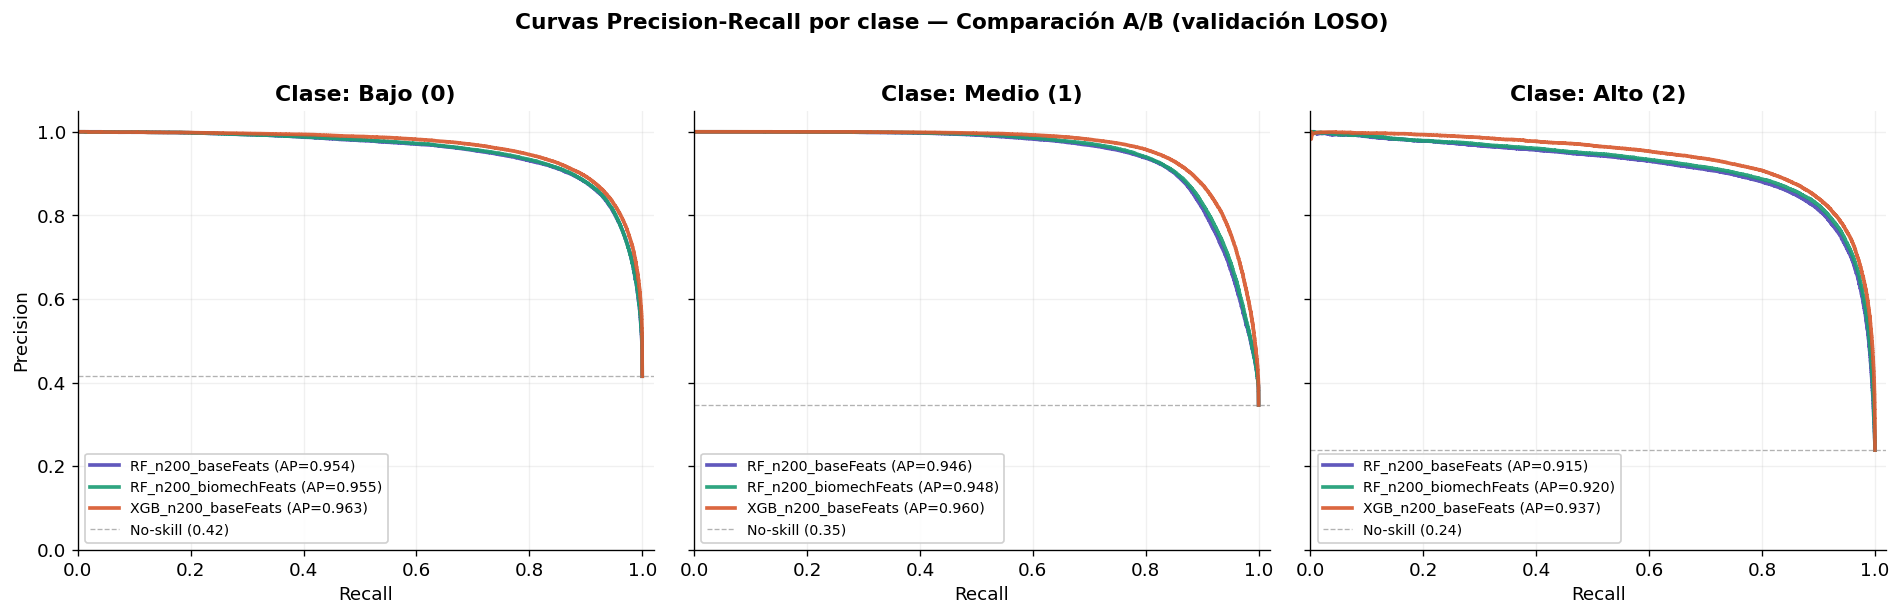

Gráfico PR guardado en: reports\figures\05_ab_pr_curves_comparison.png


In [9]:
figures_dir = Path(cfg["paths"]["figures"])
figures_dir.mkdir(parents=True, exist_ok=True)

pr_path = figures_dir / "05_ab_pr_curves_comparison.png"
plot_pr_curves_comparison(results, pr_path, n_classes=3)
print(f"Gráfico PR guardado en: {pr_path}")

## 7. Complemento — Matrices de confusión comparadas

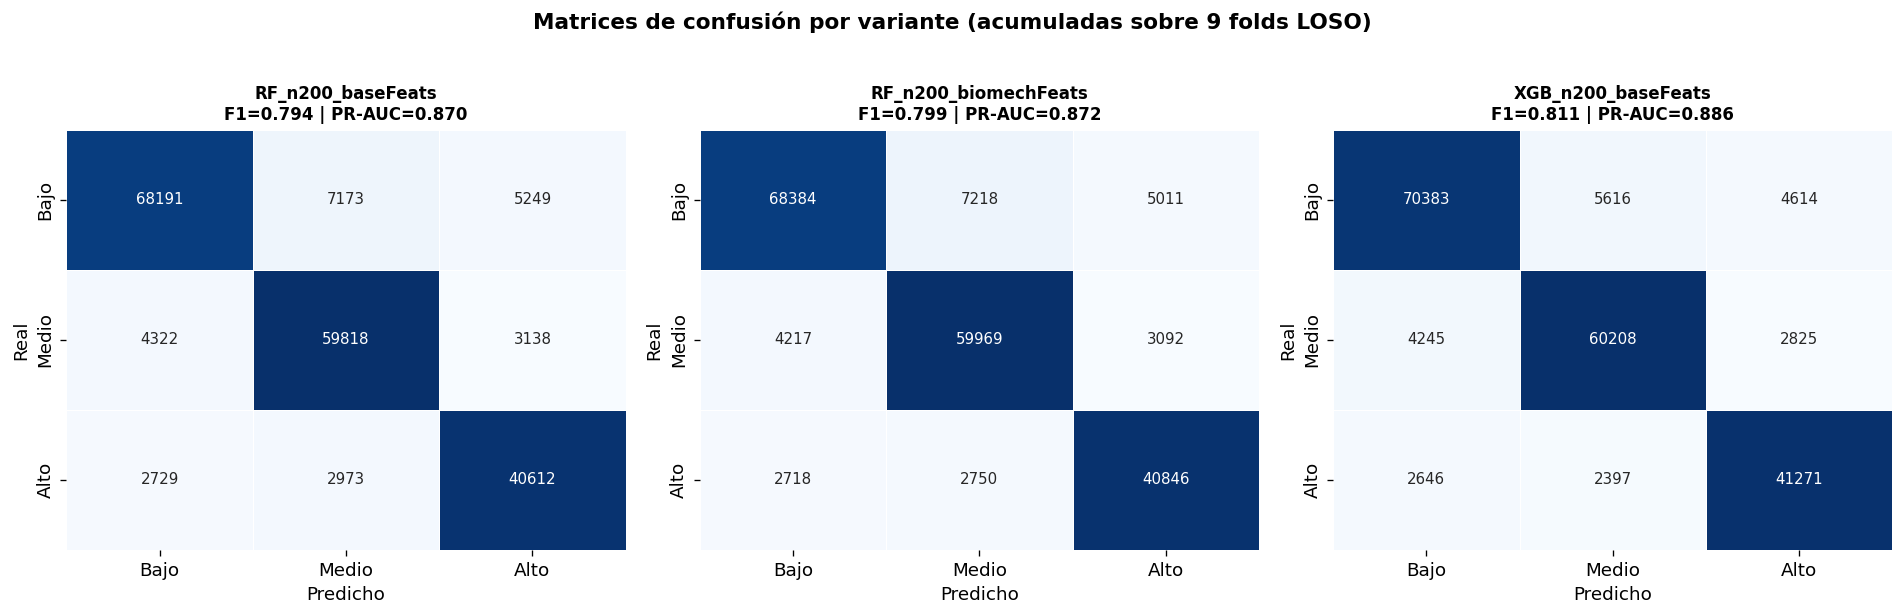

Matrices de confusión guardadas en: reports\figures\06_ab_confusion_matrices.png


In [10]:
cm_path = figures_dir / "06_ab_confusion_matrices.png"
plot_confusion_matrices_comparison(results, cm_path)
print(f"Matrices de confusión guardadas en: {cm_path}")

## 8. Logging persistente en CSV

Cada variante se registra en `logs/metrics_experimentos.csv`
con su `exp_id` único, configuración y métricas.

In [11]:
log_csv_path = Path(cfg["paths"]["log_csv"])

for result in results:
    record = make_record(
        exp_name    = result["exp_name"],
        model       = "random_forest" if result["exp_name"].startswith("RF_") else "gradient_boosting",
        feature_set = "biomech" if "biomechFeats" in result["exp_name"] else "base",
        metrics     = result,
        config      = {
            "cv_strategy": f"{cfg['validation']['cv_strategy']}-LOSO",
            "n_folds":     cfg["validation"]["n_folds"],
            "seed":        SEED,
        },
        notes       = result.get("notes", ""),
        log_path    = str(figures_dir / f"{result['exp_name']}.json"),
        csv_path    = log_csv_path,
    )
    append_experiment(record, log_csv_path)
    print(f"  Registrado: {record['exp_id']} | {record['exp_name']}")

print(f"\nHistorial completo en: {log_csv_path}")

  Registrado: EXP001 | RF_n200_baseFeats
  Registrado: EXP002 | RF_n200_biomechFeats
  Registrado: EXP003 | XGB_n200_baseFeats

Historial completo en: logs\metrics_experimentos.csv


## 9. Decisión final: adoptar / descartar

In [12]:
decision = make_decision(
    results,
    threshold_improvement=cfg["decision"]["min_improvement"],
)

print("="*70)
print("DECISIÓN FINAL DEL EXPERIMENTO A/B")
print("="*70)
print(f"\nBaseline: {decision['baseline_name']}")
print(f"  F1-Macro: {decision['baseline_f1']:.4f}\n")
print(f"{'Variante':<28} {'ΔF1':>8} {'ΔPR-AUC':>10} {'ΔTime':>8} {'Decisión':>12}")
print("-" * 70)
for d in decision["decisions"]:
    sign = "+" if d["delta_f1"] >= 0 else ""
    print(
        f"{d['variant_name']:<28} {sign}{d['delta_f1']:>7.4f} "
        f"{sign}{d['delta_pr_auc']:>9.4f} {d['time_overhead_s']:>+7.1f}s "
        f"{d['decision']:>12}"
    )
print("\n" + "="*70)
print(f"Mejor variante global: {decision['best_variant']}")
print("="*70)

DECISIÓN FINAL DEL EXPERIMENTO A/B

Baseline: RF_n200_baseFeats
  F1-Macro: 0.7942

Variante                          ΔF1    ΔPR-AUC    ΔTime     Decisión
----------------------------------------------------------------------
RF_n200_biomechFeats         + 0.0048 +   0.0022  +151.5s    DESCARTAR
XGB_n200_baseFeats           + 0.0166 +   0.0166  -368.2s      ADOPTAR

Mejor variante global: XGB_n200_baseFeats
